### Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression   
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [2]:
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

NumPy version: 2.2.6
Pandas version: 2.3.3


### Load & Read Dataset

In [3]:
dataset_path = "./datasets/auto-mpg.csv"
df = pd.read_csv(dataset_path)

In [4]:
# Dataset Dimensions
df.shape

(398, 9)

In [5]:
# First 5 rows of the dataset
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [6]:
# Last 5 rows of the dataset
df.tail()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger
397,31.0,4,119.0,82,2720,19.4,82,1,chevy s-10


In [7]:
# Ramdom 10 rows of the dataset
df.sample(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
273,23.9,4,119.0,97,2405,14.9,78,3,datsun 200-sx
377,31.0,4,91.0,68,1970,17.6,82,3,mazda glc custom
250,19.4,8,318.0,140,3735,13.2,78,1,dodge diplomat
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
145,32.0,4,83.0,61,2003,19.0,74,3,datsun 710
347,37.0,4,85.0,65,1975,19.4,81,3,datsun 210 mpg
316,19.1,6,225.0,90,3381,18.7,80,1,dodge aspen
294,34.1,4,86.0,65,1975,15.2,79,3,maxda glc deluxe
232,16.0,8,351.0,149,4335,14.5,77,1,ford thunderbird
93,14.0,8,318.0,150,4237,14.5,73,1,plymouth fury gran sedan


### Dataset Information

In [8]:
df.info()

# ----------------------------------------------------------------
# Observations:

# No missing values in the dataset.
# In dataset 2 columns are of object type, 4 columns are of int64 type and 3 columns are of float64 type.
# ----------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [9]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [10]:
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6
cylinders,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
displacement,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
weight,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acceleration,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
model year,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
origin,398.0,1.572864,0.802055,1.0,1.000,1.0,2.000,3.0


In [11]:
df.describe(include="O").T

,count,unique,top,freq
horsepower,398,94,150,22
car name,398,305,ford pinto,6


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

In [14]:
numerical_cols = ["mpg", "displacement", "horsepower", "weight", "acceleration"]
categorical_cols = ["cylinders", "model year", "origin", "car name"]

In [15]:
df["horsepower"] = df["horsepower"].apply(pd.to_numeric, errors="coerce")
df["cylinders"] = df["cylinders"].astype("category")
df["model year"] = df["model year"].astype("category")
df["origin"] = df["origin"].astype("category")

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           398 non-null    float64 
 1   cylinders     398 non-null    category
 2   displacement  398 non-null    float64 
 3   horsepower    392 non-null    float64 
 4   weight        398 non-null    int64   
 5   acceleration  398 non-null    float64 
 6   model year    398 non-null    category
 7   origin        398 non-null    category
 8   car name      398 non-null    object  
dtypes: category(3), float64(4), int64(1), object(1)
memory usage: 20.9+ KB


### Univariate Analysis

In [17]:
def num_univariate_analysis(df, col):
    print("-"*100)
    print(f"Feature Name: {col}")
    print("\nDescriptive Analysis")
    print(df[col].describe())
    print(f"\nSkewness: {np.round(df[col].skew(), 2)}")

    fig, ax = plt.subplots(2,1, figsize=(10,8), sharex=True)
    sns.histplot(df, x=col, kde=True, ax=ax[0])
    sns.boxplot(df, x=col, ax=ax[1])   
    
    ax[0].set_title(f"Distribution of {col}")

    plt.tight_layout()
    plt.show()

----------------------------------------------------------------------------------------------------
Feature Name: mpg

Descriptive Analysis
count    398.000000
mean      23.514573
std        7.815984
min        9.000000
25%       17.500000
50%       23.000000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64

Skewness: 0.46


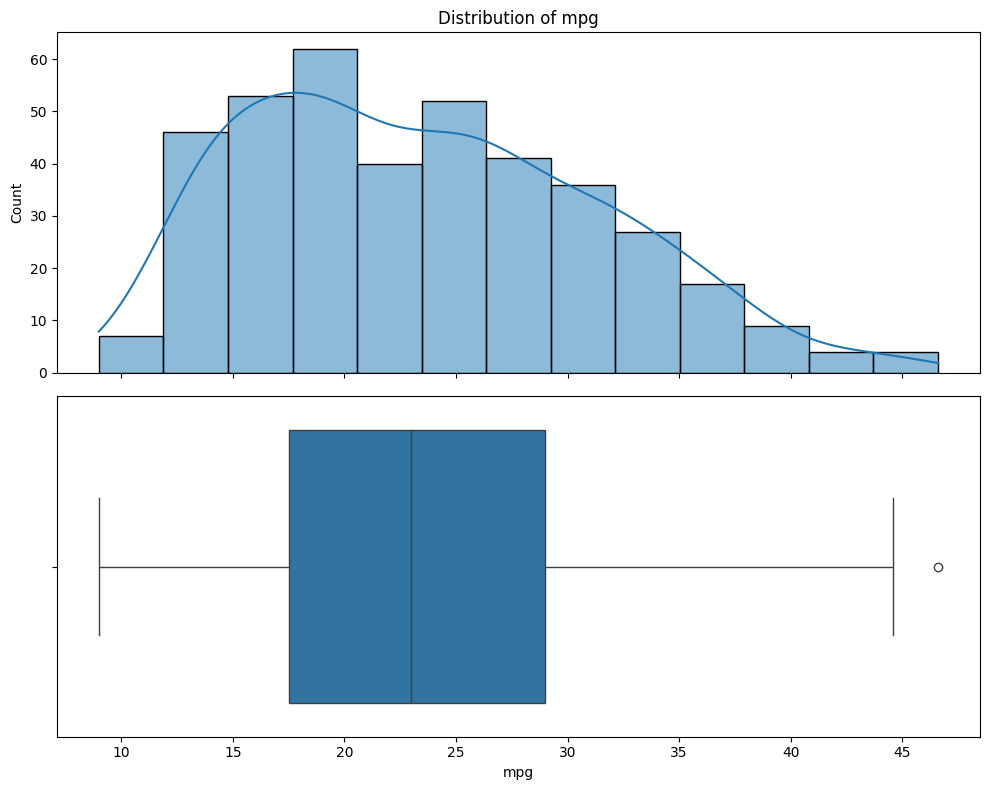

----------------------------------------------------------------------------------------------------
Feature Name: displacement

Descriptive Analysis
count    398.000000
mean     193.425879
std      104.269838
min       68.000000
25%      104.250000
50%      148.500000
75%      262.000000
max      455.000000
Name: displacement, dtype: float64

Skewness: 0.72


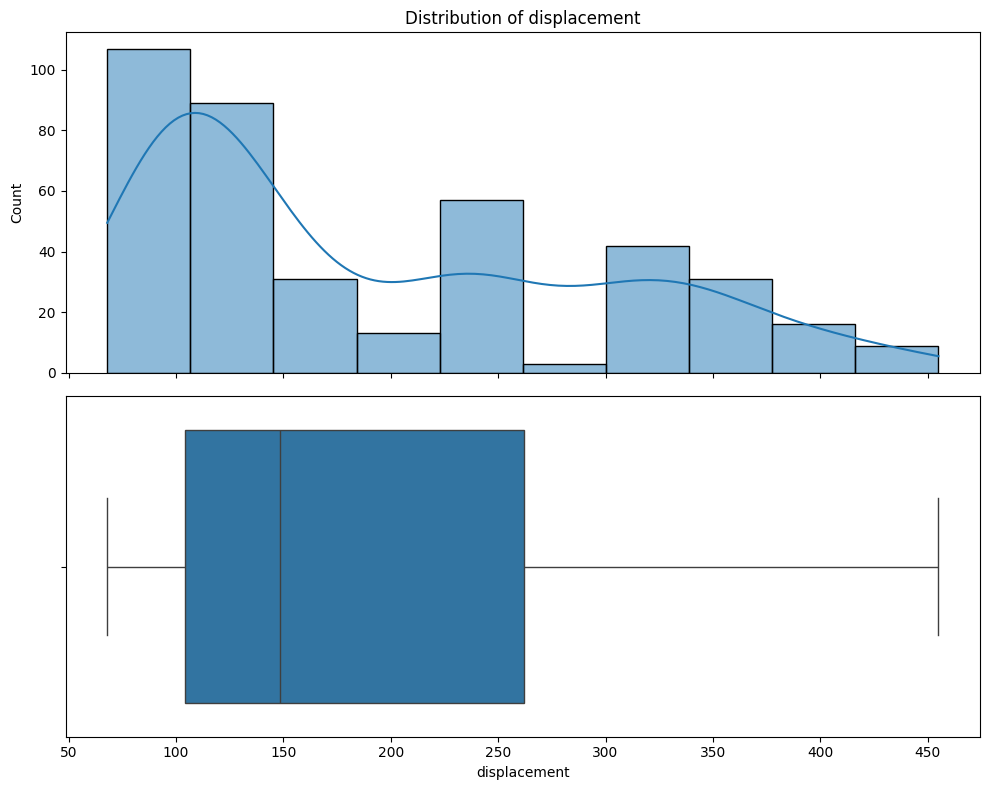

----------------------------------------------------------------------------------------------------
Feature Name: horsepower

Descriptive Analysis
count    392.000000
mean     104.469388
std       38.491160
min       46.000000
25%       75.000000
50%       93.500000
75%      126.000000
max      230.000000
Name: horsepower, dtype: float64

Skewness: 1.09


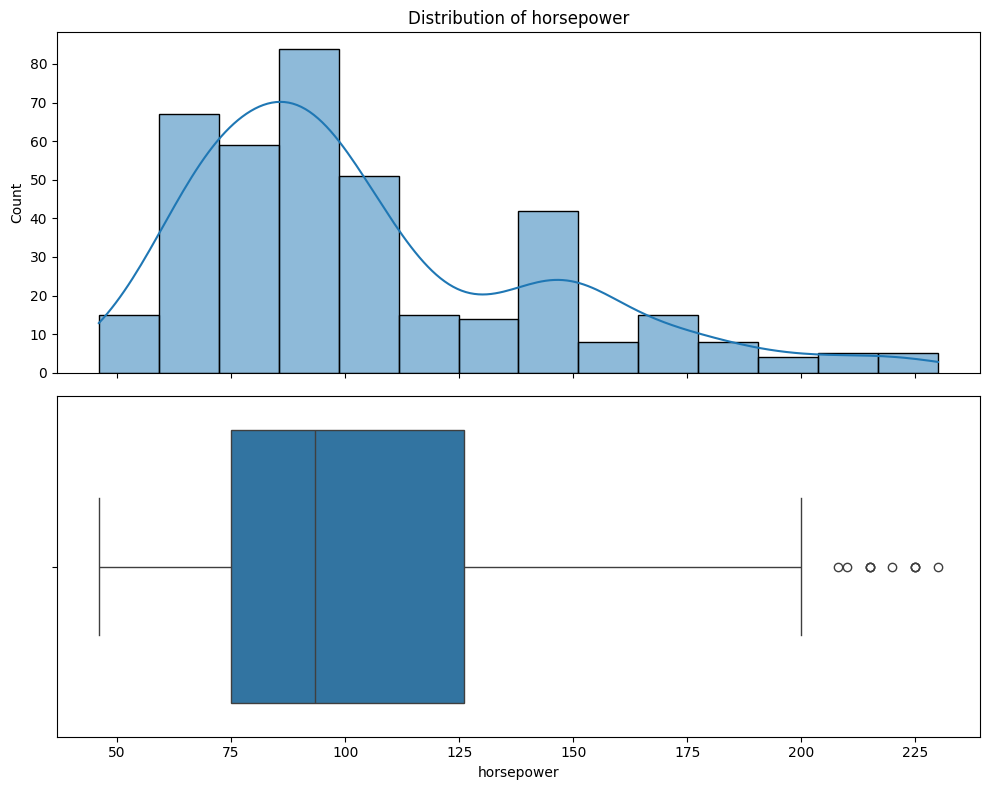

----------------------------------------------------------------------------------------------------
Feature Name: weight

Descriptive Analysis
count     398.000000
mean     2970.424623
std       846.841774
min      1613.000000
25%      2223.750000
50%      2803.500000
75%      3608.000000
max      5140.000000
Name: weight, dtype: float64

Skewness: 0.53


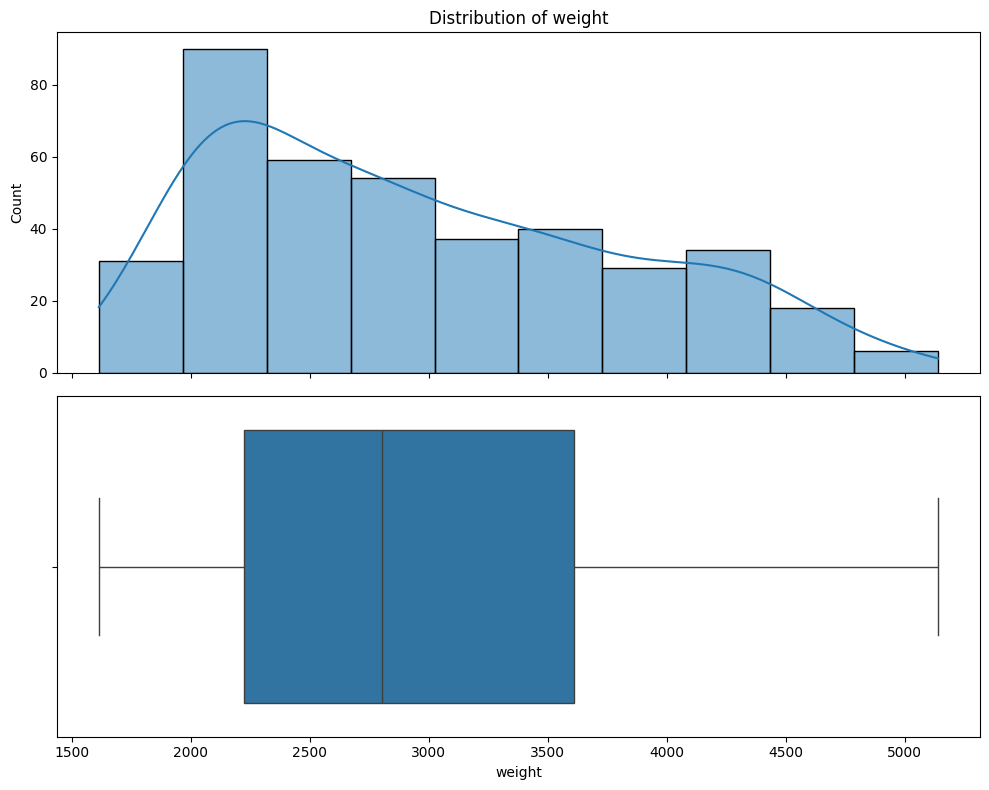

----------------------------------------------------------------------------------------------------
Feature Name: acceleration

Descriptive Analysis
count    398.000000
mean      15.568090
std        2.757689
min        8.000000
25%       13.825000
50%       15.500000
75%       17.175000
max       24.800000
Name: acceleration, dtype: float64

Skewness: 0.28


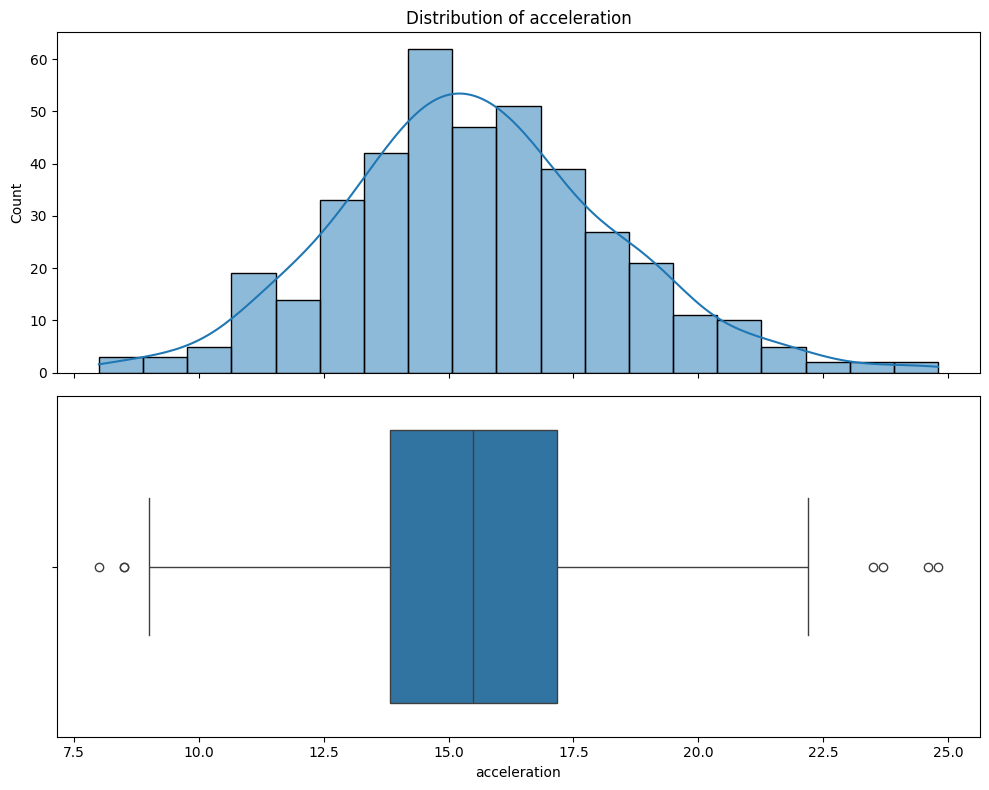

In [18]:
for col in numerical_cols:
    num_univariate_analysis(df, col)

In [19]:
def cat_univariate_analysis(df, col):
    print("-"*100)
    print(f"Feature Name: {col}")

    print("\nValue Counts:")
    print(df[col].value_counts().head())

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    sns.countplot(df, x=col, ax=ax[0])
    ax[0].set_title(f"Countplot of {col}")   
    ax[0].set_xlabel(col)
    ax[0].set_ylabel("Count")

    df[col].value_counts().head(10).plot.pie(
        autopct="%1.1f%%", ax=ax[1], startangle=90, cmap="tab20"
    )
    ax[1].set_ylabel("")
    ax[1].set_title(f"Pie Chart of {col}")

    plt.tight_layout()
    plt.show()

----------------------------------------------------------------------------------------------------
Feature Name: cylinders

Value Counts:
cylinders
4    204
8    103
6     84
3      4
5      3
Name: count, dtype: int64


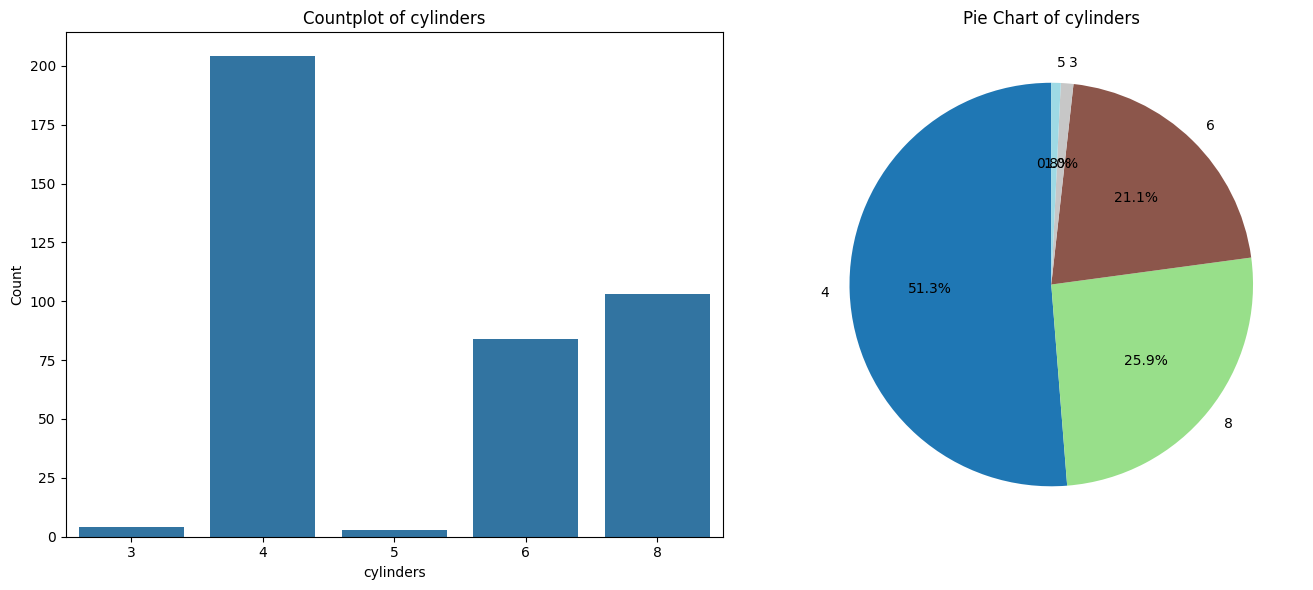

----------------------------------------------------------------------------------------------------
Feature Name: model year

Value Counts:
model year
73    40
78    36
76    34
82    31
75    30
Name: count, dtype: int64


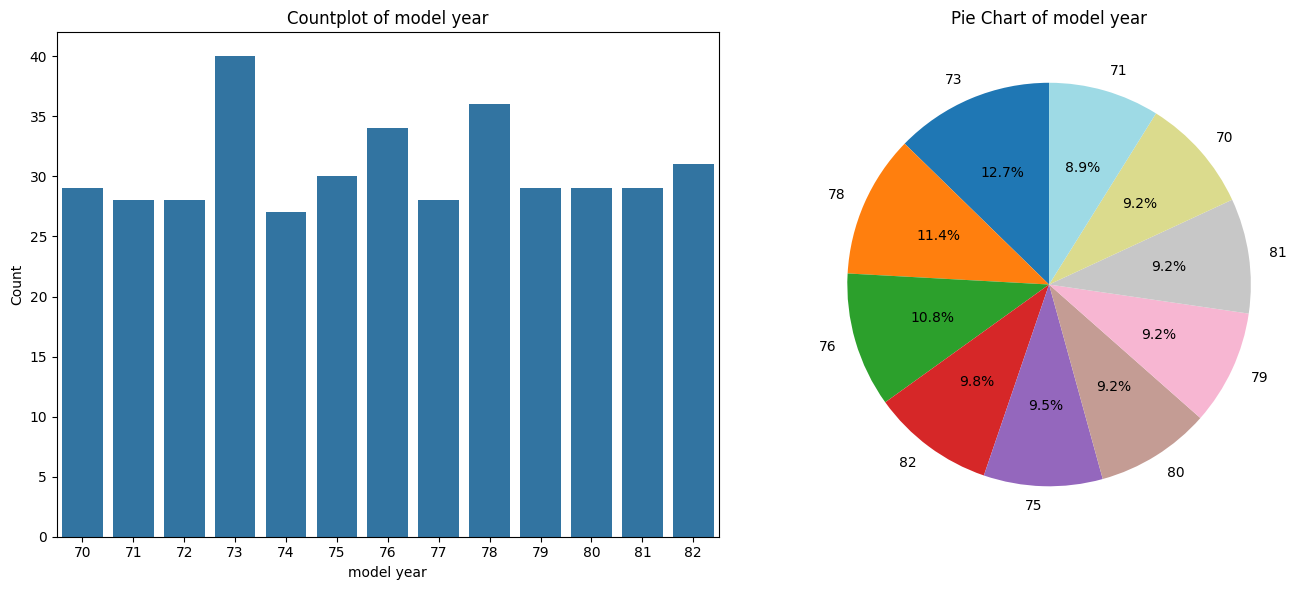

----------------------------------------------------------------------------------------------------
Feature Name: origin

Value Counts:
origin
1    249
3     79
2     70
Name: count, dtype: int64


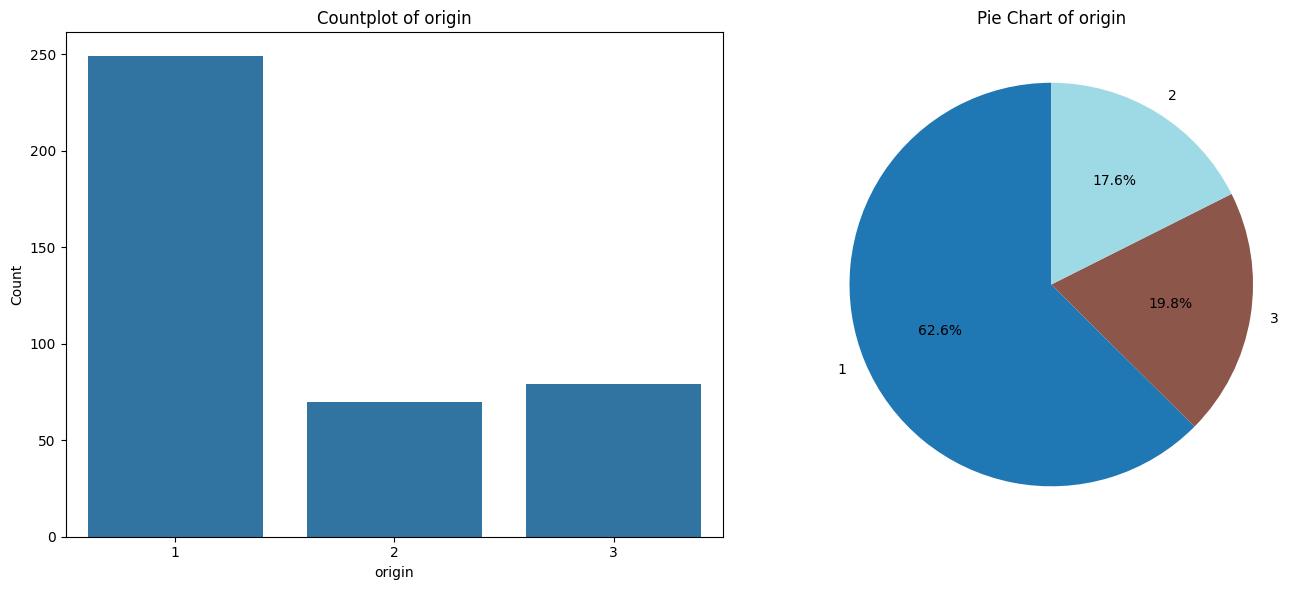

----------------------------------------------------------------------------------------------------
Feature Name: car name

Value Counts:
car name
ford pinto        6
ford maverick     5
amc matador       5
toyota corolla    5
amc hornet        4
Name: count, dtype: int64


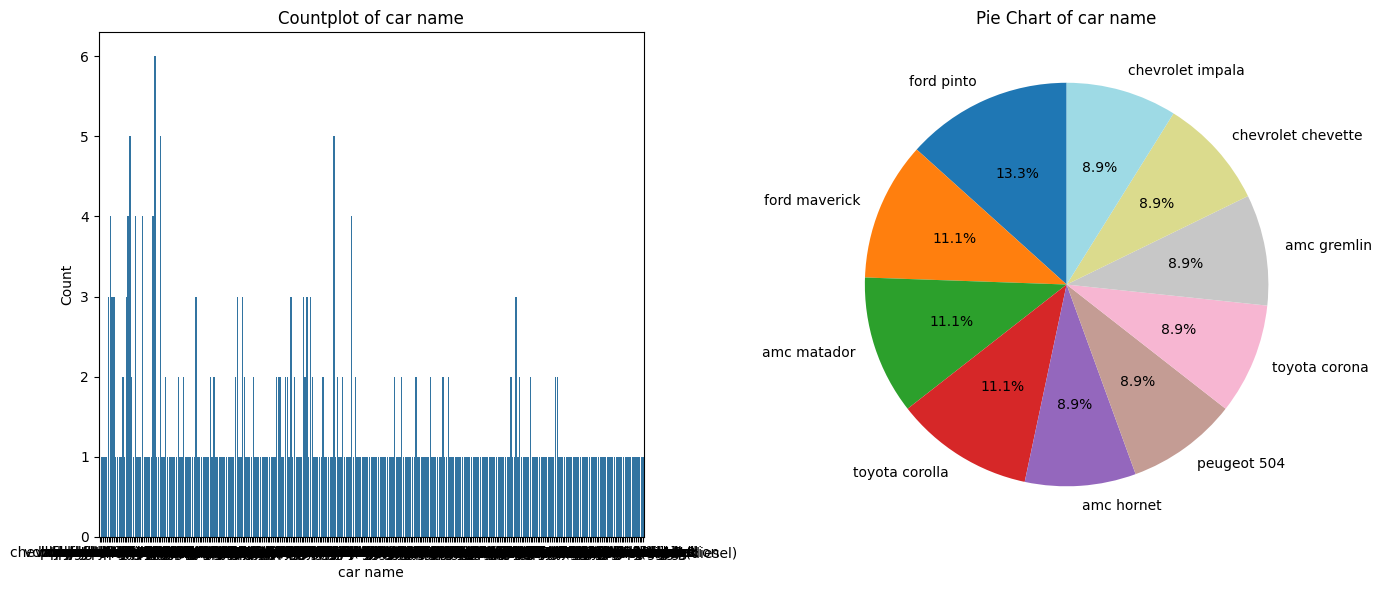

In [20]:
for col in categorical_cols:
    cat_univariate_analysis(df, col)

### Data Preparation

In [21]:
X = df.drop("mpg", axis=1)
y = df["mpg"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
df["horsepower"] = df["horsepower"].apply(pd.to_numeric, errors="coerce")
df["cylinders"] = df["cylinders"].astype("category")
df["model year"] = df["model year"].astype("category")
df["origin"] = df["origin"].astype("category")

ohe_cols = ['cylinders', 'origin', "model year"]
drop_cols = ['car name']

preprocessor = ColumnTransformer([
    ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), ohe_cols),
    ("drop", "drop", drop_cols)],  
    remainder="passthrough",
    verbose_feature_names_out=False)

In [23]:
pipeline = Pipeline([
    ("preprocessor", preprocessor.set_output(transform="pandas")),
    ("scaler", StandardScaler().set_output(transform="pandas"))
])

pipeline.fit_transform(X_train)

,cylinders_4,cylinders_5,cylinders_6,cylinders_8,origin_2,origin_3,model year_71,model year_72,model year_73,model year_74,...,model year_77,model year_78,model year_79,model year_80,model year_81,model year_82,displacement,horsepower,weight,acceleration
3,-1.019049,-0.09759,-0.53128,1.739344,-0.462321,-0.511766,-0.252082,-0.252082,-0.334497,-0.272625,...,-0.279224,-0.328655,-0.285714,-0.298398,-0.298398,-0.252082,1.090196,1.252385,0.552826,-1.319334
18,0.981307,-0.09759,-0.53128,-0.574930,-0.462321,1.954017,-0.252082,-0.252082,-0.334497,-0.272625,...,-0.279224,-0.328655,-0.285714,-0.298398,-0.298398,-0.252082,-0.922996,-0.409753,-0.999667,-0.413182
376,0.981307,-0.09759,-0.53128,-0.574930,-0.462321,1.954017,-0.252082,-0.252082,-0.334497,-0.272625,...,-0.279224,-0.328655,-0.285714,-0.298398,-0.298398,3.966969,-0.981350,-0.945926,-1.124772,0.927922
248,0.981307,-0.09759,-0.53128,-0.574930,-0.462321,1.954017,-0.252082,-0.252082,-0.334497,-0.272625,...,-0.279224,3.042707,-0.285714,-0.298398,-0.298398,-0.252082,-0.981350,-1.160396,-1.392854,0.275493
177,0.981307,-0.09759,-0.53128,-0.574930,2.163001,-0.511766,-0.252082,-0.252082,-0.334497,-0.272625,...,-0.279224,-0.328655,-0.285714,-0.298398,-0.298398,-0.252082,-0.747936,-0.222092,-0.327675,-0.231952
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,-1.019049,-0.09759,-0.53128,-0.574930,-0.462321,1.954017,-0.252082,3.966969,-0.334497,-0.272625,...,-0.279224,-0.328655,-0.285714,-0.298398,-0.298398,-0.252082,-1.185587,-0.168475,-0.761372,-0.775643
106,-1.019049,-0.09759,-0.53128,1.739344,-0.462321,-0.511766,-0.252082,-0.252082,2.989565,-0.272625,...,-0.279224,-0.328655,-0.285714,-0.298398,-0.298398,-0.252082,1.537573,2.056645,1.822940,-1.138103
270,0.981307,-0.09759,-0.53128,-0.574930,-0.462321,1.954017,-0.252082,-0.252082,-0.334497,-0.272625,...,-0.279224,3.042707,-0.285714,-0.298398,-0.298398,-0.252082,-0.563150,-0.222092,-0.540949,-0.304444
348,0.981307,-0.09759,-0.53128,-0.574930,-0.462321,1.954017,-0.252082,-0.252082,-0.334497,-0.272625,...,-0.279224,-0.328655,-0.285714,-0.298398,3.351234,-0.252082,-1.000801,-1.106778,-1.094985,0.601707


### Model Training

In [24]:
models = {
    "linear_regression": LinearRegression(),
    "random_forest": RandomForestRegressor(),
    "xgboost": xgb.XGBRegressor()
}

results = {}

for name, model in models.items():
    X_train_transformed = pipeline.fit_transform(X_train).dropna(axis=1)
    model.fit(X_train_transformed, y_train)

    X_test_transformed = pipeline.transform(X_test).dropna(axis=1)
    y_pred = model.predict(X_test_transformed)

    r2 = r2_score(y_test, y_pred)
    results[name] = r2

results

{'linear_regression': 0.8620225289931268,
 'random_forest': 0.8771935343966283,
 'xgboost': 0.8057691807224074}

In [25]:
models = {
    "linear_regression": LinearRegression(),
    "random_forest": RandomForestRegressor(n_estimators=200, random_state=42, max_depth=6),
    "xgboost": xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

results = {}

for name, model in models.items():
    X_train_transformed = pipeline.fit_transform(X_train).dropna(axis=1)
    model.fit(X_train_transformed, y_train)

    X_test_transformed = pipeline.transform(X_test).dropna(axis=1)
    y_pred = model.predict(X_test_transformed)

    r2 = r2_score(y_test, y_pred)
    results[name] = r2

results

{'linear_regression': 0.8620225289931268,
 'random_forest': 0.850624934084677,
 'xgboost': 0.8598819544395654}